# Módulo 3 — Sistema de recomendación de destinos

**Proyecto:** Sistema Inteligente Integrado para RutaViva  
**Curso:** Redes Neuronales Artificiales  
**Notebook:** `01_modelo_recomendacion.ipynb`

---

## Objetivo

Construir un sistema de recomendación que sugiera destinos personalizados a los clientes de RutaViva, a partir de su historial de ratings sobre las 30 destinaciones del catálogo. Este sistema responde a la persona **Andrés** (cliente frecuente) definida en la fase Empathize del Design Thinking.

## Enfoque

Comparamos **dos enfoques de filtrado colaborativo** sobre el mismo dataset, con el objetivo de cuantificar el aporte de la no-linealidad para nuestra tarea de recomendación:

| Modelo | Tipo | Referencia |
|---|---|---|
| **Matrix Factorization (MF)** | Producto escalar de embeddings + biases | Koren et al., 2009 |
| **Neural Collaborative Filtering (NCF)** | Embeddings → MLP no lineal | He et al., 2017 |

Ambos modelos comparten la misma capa de embedding (dimensión 16), la misma función de pérdida (MSE) y los mismos hiperparámetros de entrenamiento (Adam con `lr=1e-3` y `weight_decay=1e-5`). La **única diferencia** es la forma de combinar los embeddings de usuario y de destino: producto escalar (MF) vs MLP no lineal (NCF). Esta paridad de configuración nos permite **aislar el aporte específico de la no-linealidad** sobre nuestro problema.

Esta postura comparativa — sin designar a priori un modelo "principal" — está alineada con la literatura reciente, especialmente Rendle et al. (2020) *"Neural Collaborative Filtering vs. Matrix Factorization Revisited"*, que muestra que un MF bien ajustado puede igualar o superar al NCF según la estructura del dataset.

## Decisiones de diseño clave

| Decisión | Valor | Justificación |
|---|---|---|
| Señal de entrenamiento | Reviews explícitas (rating 1-5) | Señal más informativa, problema de regresión limpio |
| Dimensión de los embeddings | 16 | Suficiente para capturar 5 arquetipos + variabilidad; PCA legible |
| Función de pérdida | MSE | Apropiada para regresión sobre ratings |
| Partición train/test | **Temporal** (train ≤ 2024-10-31, test ≥ 2024-11-01) | Simula despliegue real, coherente con Módulo 1 |
| Métricas de rating | RMSE, MAE | Estándar para predicción de ratings |
| Métricas de ranking | Precision@10, Recall@10 (relevant ⟺ rating ≥ 4) | Evalúa la calidad de las top-K recomendaciones |

## Análisis creativo

Al final del notebook validamos que los embeddings de usuario aprendidos por el modelo NCF **redescubren los 5 arquetipos latentes** del dataset, mediante un análisis PCA + comparación con el `ground_truth_arquetipos.csv` (oculto durante el entrenamiento). Este análisis hace eco directo al PCA de los embeddings de ruta realizado en el Módulo 1, garantizando coherencia metodológica entre los dos módulos.

## 0. Conexión a Google Drive

Mismo esquema que el notebook de generación del dataset. Los modelos entrenados y los archivos de metadata se guardarán en `proyecto3-rutaviva/models/`.

In [2]:
# Detectar si estamos en Google Colab o entorno local
import os
try:
    from google.colab import drive
    COLAB = True
except ImportError:
    COLAB = False

if COLAB:
    print('Ejecutando en Google Colab. Montando Drive...')
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/proyecto3-rutaviva'
    RUTA_DATA    = f'{DRIVE}/data'
    RUTA_MODELS  = f'{DRIVE}/models'
    RUTA_FIGURES = f'{DRIVE}/figures'
else:
    print('Ejecutando en entorno local.')
    # Buscar raíz del proyecto
    current_dir = os.path.abspath(os.getcwd())
    if os.path.basename(current_dir) == 'notebooks':
        PROJECT_ROOT = os.path.dirname(current_dir)
    else:
        PROJECT_ROOT = current_dir
        
    DRIVE = PROJECT_ROOT
    RUTA_DATA    = os.path.join(PROJECT_ROOT, 'streamlit_app', 'data')
    RUTA_MODELS  = os.path.join(PROJECT_ROOT, 'streamlit_app', 'models')
    RUTA_FIGURES = os.path.join(PROJECT_ROOT, 'notebooks', 'figures')

os.makedirs(RUTA_MODELS,  exist_ok=True)
os.makedirs(RUTA_FIGURES, exist_ok=True)

print('Dataset  :', RUTA_DATA)
print('Modelos  :', RUTA_MODELS)
print('Figuras  :', RUTA_FIGURES)


Mounted at /content/drive
Drive montado. Proyecto en: /content/drive/MyDrive/proyecto3-rutaviva


## 1. Importación de librerías y configuración

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA

# Reproducibilidad
SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

# Dispositivo (Colab gratuito ofrece GPU en general)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

# Estilo de gráficos coherente con Módulo 1
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Dispositivo: cpu


## 2. Carga de los datos

Cargamos las 5 tablas generadas en el notebook `00_generacion_dataset_modulo3.ipynb`. Recordemos que el archivo `ground_truth_arquetipos.csv` **no se utiliza durante el entrenamiento** — se reserva para la validación final del análisis PCA.

In [4]:
# Carga de datos utilizando RUTA_DATA dinámica
if 'RUTA_DATA' not in globals():
    RUTA_DATA = f'{DRIVE}/data'

users_df        = pd.read_csv(os.path.join(RUTA_DATA, 'users.csv'))
destinations_df = pd.read_csv(os.path.join(RUTA_DATA, 'destinations.csv'))
visits_df       = pd.read_csv(os.path.join(RUTA_DATA, 'visits.csv'),  parse_dates=['VisitDate'])
reviews_df      = pd.read_csv(os.path.join(RUTA_DATA, 'reviews.csv'), parse_dates=['VisitDate'])
ground_truth    = pd.read_csv(os.path.join(RUTA_DATA, 'ground_truth_arquetipos.csv'))

print('Tablas cargadas:')
print(f'  users        : {len(users_df):6d} filas')
print(f'  destinations : {len(destinations_df):6d} filas')
print(f'  visits       : {len(visits_df):6d} filas')
print(f'  reviews      : {len(reviews_df):6d} filas')
print(f'  ground_truth : {len(ground_truth):6d} filas  (reservado para evaluación)')


Tablas cargadas:
  users        :    900 filas
  destinations :     30 filas
  visits       :  10656 filas
  reviews      :   6930 filas
  ground_truth :    900 filas  (reservado para evaluación)


## 3. Análisis exploratorio rápido

Antes de entrenar, verificamos las propiedades clave del dataset desde la perspectiva del problema de recomendación.

### 3.1 Distribución de los ratings

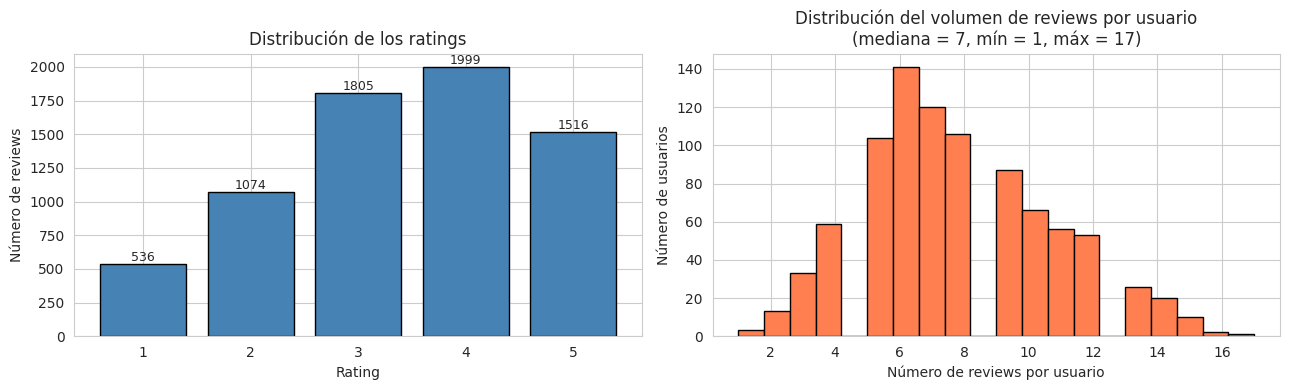


Estadísticas de ratings: media = 3.42, std = 1.21
Proporción de ratings >= 4 (relevant): 50.7%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de ratings
rating_counts = reviews_df['Rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Número de reviews')
axes[0].set_title('Distribución de los ratings')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0].text(i, v, f'{v}', ha='center', va='bottom', fontsize=9)

# Número de reviews por usuario
reviews_por_user = reviews_df.groupby('UserID').size()
axes[1].hist(reviews_por_user, bins=20, color='coral', edgecolor='black')
axes[1].set_xlabel('Número de reviews por usuario')
axes[1].set_ylabel('Número de usuarios')
axes[1].set_title(f'Distribución del volumen de reviews por usuario\n(mediana = {reviews_por_user.median():.0f}, mín = {reviews_por_user.min()}, máx = {reviews_por_user.max()})')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGURES, 'm3_01_distribucion_ratings.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'\nEstadísticas de ratings: media = {reviews_df["Rating"].mean():.2f}, std = {reviews_df["Rating"].std():.2f}')
print(f'Proporción de ratings >= 4 (relevant): {(reviews_df["Rating"] >= 4).mean()*100:.1f}%')

### 3.2 Sparsidad de la matriz user × destino

In [6]:
n_users = len(users_df)
n_dests = len(destinations_df)
n_ratings = len(reviews_df)

celdas_totales = n_users * n_dests
sparsidad = 1 - n_ratings / celdas_totales

print(f'Matriz user × destino para el entrenamiento:')
print(f'  Tamaño teórico : {n_users} × {n_dests} = {celdas_totales:,} celdas')
print(f'  Ratings obs.   : {n_ratings}')
print(f'  Sparsidad      : {sparsidad*100:.1f}%')
print(f'  Densidad       : {(1-sparsidad)*100:.1f}%')

Matriz user × destino para el entrenamiento:
  Tamaño teórico : 900 × 30 = 27,000 celdas
  Ratings obs.   : 6930
  Sparsidad      : 74.3%
  Densidad       : 25.7%


Una densidad de aproximadamente 25 % es relativamente alta para un problema de recomendación (los datasets reales como MovieLens están alrededor del 1-5 %). Esto se debe a la naturaleza sintética de los datos. Es una limitación reconocida: el modelo opera en condiciones más favorables que las reales.

## 4. Preprocesamiento

Tres pasos necesarios antes de entrenar:

1. **Codificación de IDs en índices contiguos** (PyTorch `nn.Embedding` requiere índices 0...N-1).
2. **Partición temporal train/test** (coherente con el Módulo 1).
3. **Construcción de los DataLoaders** PyTorch.

### 4.1 Codificación de IDs

Convertimos `UserID` y `DestinationID` (que arrancan en 1) en índices contiguos `user_idx` y `dest_idx` (que arrancan en 0). Guardamos los mapeos para poder volver a los IDs originales en el momento de la inferencia (Streamlit del Módulo 4).

In [7]:
# Mapeo UserID → user_idx
user_ids_unicos = sorted(reviews_df['UserID'].unique())
user_id_to_idx  = {uid: i for i, uid in enumerate(user_ids_unicos)}
idx_to_user_id  = {i: uid for uid, i in user_id_to_idx.items()}

# Mapeo DestinationID → dest_idx
dest_ids_unicos = sorted(destinations_df['DestinationID'].unique())
dest_id_to_idx  = {did: i for i, did in enumerate(dest_ids_unicos)}
idx_to_dest_id  = {i: did for did, i in dest_id_to_idx.items()}

n_users_train = len(user_id_to_idx)
n_dests_train = len(dest_id_to_idx)

print(f'Usuarios únicos con review: {n_users_train}')
print(f'Destinaciones únicas      : {n_dests_train}')

# Aplicamos el mapeo al DataFrame de reviews
reviews_df['user_idx'] = reviews_df['UserID'].map(user_id_to_idx)
reviews_df['dest_idx'] = reviews_df['DestinationID'].map(dest_id_to_idx)
reviews_df.head()

Usuarios únicos con review: 900
Destinaciones únicas      : 30


,ReviewID,UserID,DestinationID,Rating,VisitDate,user_idx,dest_idx
0,1,1,14,4,2024-01-11,0,13
1,2,1,29,4,2023-05-25,0,28
2,3,1,2,5,2024-12-05,0,1
3,4,1,10,3,2023-03-10,0,9
4,5,1,26,2,2024-05-07,0,25


### 4.2 Partición temporal train / test

Cortamos la cronología en `2024-11-01`, idéntico al Módulo 1, para reflejar un despliegue real: el modelo se entrena con datos pasados (enero 2023 – octubre 2024) y se evalúa sobre el futuro inmediato (noviembre-diciembre 2024).

> **Nota importante.** Verificamos que cada usuario del test esté también presente en el train (de lo contrario, el modelo no podría predecir nada para él — problema *cold-start*). Si algunos usuarios solo aparecen en el test, los excluimos del test con un mensaje claro.

In [8]:
FECHA_CORTE = pd.Timestamp('2024-11-01')

train_df = reviews_df[reviews_df['VisitDate'] <  FECHA_CORTE].copy().reset_index(drop=True)
test_df  = reviews_df[reviews_df['VisitDate'] >= FECHA_CORTE].copy().reset_index(drop=True)

# Verificación cold-start: los users del test deben estar en el train
users_train = set(train_df['user_idx'])
users_test  = set(test_df['user_idx'])
cold_users  = users_test - users_train

if cold_users:
    print(f'  Atención: {len(cold_users)} usuarios solo aparecen en el test. Los excluimos.')
    test_df = test_df[~test_df['user_idx'].isin(cold_users)].reset_index(drop=True)

# Lo mismo para los destinos
dests_train = set(train_df['dest_idx'])
dests_test  = set(test_df['dest_idx'])
cold_dests  = dests_test - dests_train
if cold_dests:
    print(f'  Atención: {len(cold_dests)} destinos solo aparecen en el test. Los excluimos.')
    test_df = test_df[~test_df['dest_idx'].isin(cold_dests)].reset_index(drop=True)

print(f'\nPartición temporal:')
print(f'  Train (≤ 2024-10-31) : {len(train_df):5d} reviews')
print(f'  Test  (≥ 2024-11-01) : {len(test_df):5d} reviews')
print(f'  Ratio train/test     : {len(train_df)/(len(train_df)+len(test_df))*100:.1f}% / {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%')

  Atención: 2 usuarios solo aparecen en el test. Los excluimos.

Partición temporal:
  Train (≤ 2024-10-31) :  6371 reviews
  Test  (≥ 2024-11-01) :   557 reviews
  Ratio train/test     : 92.0% / 8.0%


### 4.3 Dataset y DataLoaders de PyTorch

Definimos una clase `RatingsDataset` que devuelve, para cada review: `(user_idx, dest_idx, rating)`. El `DataLoader` se encarga del batching y del shuffling durante el entrenamiento.

In [9]:
class RatingsDataset(Dataset):
    """Dataset PyTorch para ratings explícitos.

    Cada elemento es un triplete (user_idx, dest_idx, rating).
    Los índices son enteros (entrada de `nn.Embedding`),
    el rating es un float (objetivo de regresión MSE).
    """
    def __init__(self, df):
        self.users   = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.dests   = torch.tensor(df['dest_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['Rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.dests[idx], self.ratings[idx]

BATCH_SIZE = 256

train_dataset = RatingsDataset(train_df)
test_dataset  = RatingsDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}  ({len(train_dataset)} ejemplos)')
print(f'Test  batches: {len(test_loader)}  ({len(test_dataset)} ejemplos)')

Train batches: 25  (6371 ejemplos)
Test  batches: 3  (557 ejemplos)


## 5. Modelo 1 — Matrix Factorization

### Principio

La factorización matricial es el método clásico de filtrado colaborativo (Koren et al., 2009). La idea es representar a cada usuario $u$ y a cada destino $d$ por vectores latentes $\mathbf{p}_u, \mathbf{q}_d \in \mathbb{R}^{16}$ y predecir el rating como:

$$
\hat{r}_{u,d} = \mu + b_u + b_d + \mathbf{p}_u^\top \mathbf{q}_d
$$

donde:
- $\mu$ es el rating medio global (constante).
- $b_u$ es el bias del usuario (cuánto califica este usuario en general por encima/debajo del promedio).
- $b_d$ es el bias del destino (cuánto califican los usuarios este destino en general).
- $\mathbf{p}_u^\top \mathbf{q}_d$ captura la interacción usuario-destino.

Los biases son fundamentales: capturan parte importante de la señal sin necesidad de la interacción latente.

In [10]:
class MatrixFactorization(nn.Module):
    """Filtrado colaborativo por factorización matricial con biases.

    Referencia: Koren, Y., Bell, R., & Volinsky, C. (2009).
    Matrix factorization techniques for recommender systems. IEEE Computer, 42(8).
    """
    def __init__(self, n_users, n_dests, embedding_dim=8, rating_medio=0.0):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embedding_dim)
        self.dest_emb = nn.Embedding(n_dests, embedding_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.dest_bias = nn.Embedding(n_dests, 1)
        # Bias global = rating medio del train (constante, no aprendible)
        self.register_buffer('global_bias', torch.tensor(rating_medio, dtype=torch.float32))

        # Inicialización: embeddings pequeños, biases a cero
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.dest_emb.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.dest_bias.weight)

    def forward(self, u_idx, d_idx):
        u = self.user_emb(u_idx)              # (batch, 16)
        d = self.dest_emb(d_idx)              # (batch, 16)
        bu = self.user_bias(u_idx).squeeze(1) # (batch,)
        bd = self.dest_bias(d_idx).squeeze(1) # (batch,)
        dot = (u * d).sum(dim=1)              # producto escalar (batch,)
        return self.global_bias + bu + bd + dot

EMBEDDING_DIM = 8

rating_medio_train = train_df['Rating'].mean()

model_mf = MatrixFactorization(n_users_train, n_dests_train,
                                embedding_dim=EMBEDDING_DIM,
                                rating_medio=rating_medio_train).to(device)

n_params_mf = sum(p.numel() for p in model_mf.parameters() if p.requires_grad)
print(model_mf)
print(f'\nParámetros entrenables: {n_params_mf:,}')
print(f'Rating medio del train (bias global): {rating_medio_train:.3f}')

MatrixFactorization(
  (user_emb): Embedding(900, 8)
  (dest_emb): Embedding(30, 8)
  (user_bias): Embedding(900, 1)
  (dest_bias): Embedding(30, 1)
)

Parámetros entrenables: 8,370
Rating medio del train (bias global): 3.414


### Entrenamiento del MF

Definimos una función `entrenar_modelo` genérica que reutilizaremos para el NCF. Aplica:
- Pérdida MSE
- Optimizador Adam (`lr=1e-3`)
- Regularización L2 (`weight_decay=1e-5`) sobre todos los parámetros del modelo

**¿Por qué regularización L2?** Sin ella, los embeddings pueden crecer libremente para minimizar el MSE en el train, lo que produce un sobreajuste progresivo (el train sigue bajando mientras el test estanca). La regularización L2 penaliza los pesos grandes y estabiliza la convergencia. Es una práctica estándar en factorización matricial desde Koren et al. (2009). Aplicamos el mismo valor a los dos modelos para garantizar una comparación equitativa.

In [11]:
def entrenar_modelo(model, train_loader, test_loader, n_epochs=30, lr=1e-3, weight_decay=1e-4, nombre='modelo'):
    """Bucle de entrenamiento estándar.

    Devuelve dos listas: history_train y history_test (RMSE por época).
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history_train, history_test = [], []

    for epoch in range(1, n_epochs + 1):
        # --- Entrenamiento ---
        model.train()
        suma_loss_train, n_train = 0.0, 0
        for u, d, r in train_loader:
            u, d, r = u.to(device), d.to(device), r.to(device)
            optimizer.zero_grad()
            r_pred = model(u, d)
            loss = criterion(r_pred, r)
            loss.backward()
            optimizer.step()
            suma_loss_train += loss.item() * len(r)
            n_train += len(r)
        rmse_train = np.sqrt(suma_loss_train / n_train)
        history_train.append(rmse_train)

        # --- Evaluación sobre test ---
        model.eval()
        suma_loss_test, n_test = 0.0, 0
        with torch.no_grad():
            for u, d, r in test_loader:
                u, d, r = u.to(device), d.to(device), r.to(device)
                r_pred = model(u, d)
                loss = criterion(r_pred, r)
                suma_loss_test += loss.item() * len(r)
                n_test += len(r)
        rmse_test = np.sqrt(suma_loss_test / n_test)
        history_test.append(rmse_test)

        if epoch == 1 or epoch % 5 == 0 or epoch == n_epochs:
            print(f'  [{nombre}] Época {epoch:3d}/{n_epochs}  RMSE train = {rmse_train:.4f}  RMSE test = {rmse_test:.4f}')

    return history_train, history_test


print('Entrenamiento del modelo MF:')
hist_mf_train, hist_mf_test = entrenar_modelo(model_mf, train_loader, test_loader,
                                                n_epochs=30, nombre='MF')

Entrenamiento del modelo MF:
  [MF] Época   1/30  RMSE train = 1.2073  RMSE test = 1.1780
  [MF] Época   5/30  RMSE train = 1.1844  RMSE test = 1.1692
  [MF] Época  10/30  RMSE train = 1.1525  RMSE test = 1.1581
  [MF] Época  15/30  RMSE train = 1.1028  RMSE test = 1.1392
  [MF] Época  20/30  RMSE train = 1.0249  RMSE test = 1.1073
  [MF] Época  25/30  RMSE train = 0.9275  RMSE test = 1.0699
  [MF] Época  30/30  RMSE train = 0.8305  RMSE test = 1.0399


## 6. Modelo 2 — Neural Collaborative Filtering

### Principio

El NCF (He et al., 2017) sustituye el producto escalar del MF por un MLP que aprende una **interacción no-lineal** entre los embeddings de usuario y de destino:

$$
\hat{r}_{u,d} = \text{MLP}\big([\mathbf{p}_u, \mathbf{q}_d]\big)
$$

Donde $[\cdot, \cdot]$ denota la concatenación, y el MLP es una red feedforward de dos capas ocultas con activaciones ReLU.

**¿Por qué un MLP?** El producto escalar del MF impone una forma específica de interacción (lineal en cada componente). Un MLP, al ser un aproximador universal, puede capturar interacciones más complejas — por ejemplo, *"si el usuario tiene una afinidad alta por la categoría 'playa' Y media por la categoría 'cultural', le gustará Cartagena más que la suma de los dos efectos"*.

Mantenemos exactamente la misma capa de embedding (dim 16) y la misma función de pérdida (MSE), de manera que **la única diferencia es la no-linealidad del MLP**.

In [12]:
class NeuralCF(nn.Module):
    """Neural Collaborative Filtering.

    Concatenación de los embeddings user/dest → MLP → rating.

    Referencia: He, X., Liao, L., Zhang, H., Nie, L., Hu, X., & Chua, T.-S. (2017).
    Neural Collaborative Filtering. WWW 2017.
    """
    def __init__(self, n_users, n_dests, embedding_dim=8, hidden_dims=(64, 32)):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embedding_dim)
        self.dest_emb = nn.Embedding(n_dests, embedding_dim)

        # MLP: input = 2*embedding_dim (concatenación), output = 1 rating
        layers = []
        input_dim = 2 * embedding_dim
        for h in hidden_dims:
            layers += [nn.Linear(input_dim, h), nn.ReLU()]
            input_dim = h
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)

        # Inicialización
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.dest_emb.weight, std=0.1)

    def forward(self, u_idx, d_idx):
        u = self.user_emb(u_idx)            # (batch, 16)
        d = self.dest_emb(d_idx)            # (batch, 16)
        x = torch.cat([u, d], dim=1)        # (batch, 32)
        out = self.mlp(x).squeeze(1)        # (batch,)
        return out

model_ncf = NeuralCF(n_users_train, n_dests_train,
                      embedding_dim=EMBEDDING_DIM,
                      hidden_dims=(64, 32)).to(device)

n_params_ncf = sum(p.numel() for p in model_ncf.parameters() if p.requires_grad)
print(model_ncf)
print(f'\nParámetros entrenables: {n_params_ncf:,}')
print(f'(vs MF: {n_params_mf:,} parámetros — +{n_params_ncf-n_params_mf:,} para el MLP)')

NeuralCF(
  (user_emb): Embedding(900, 8)
  (dest_emb): Embedding(30, 8)
  (mlp): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros entrenables: 10,641
(vs MF: 8,370 parámetros — +2,271 para el MLP)


In [13]:
print('Entrenamiento del modelo NCF (principal):')
hist_ncf_train, hist_ncf_test = entrenar_modelo(model_ncf, train_loader, test_loader,
                                                  n_epochs=30, nombre='NCF')

Entrenamiento del modelo NCF (principal):
  [NCF] Época   1/30  RMSE train = 3.2925  RMSE test = 3.0423
  [NCF] Época   5/30  RMSE train = 1.1807  RMSE test = 1.1725
  [NCF] Época  10/30  RMSE train = 1.1031  RMSE test = 1.1883
  [NCF] Época  15/30  RMSE train = 1.0744  RMSE test = 1.2208
  [NCF] Época  20/30  RMSE train = 1.0656  RMSE test = 1.2293
  [NCF] Época  25/30  RMSE train = 1.0562  RMSE test = 1.2291
  [NCF] Época  30/30  RMSE train = 1.0328  RMSE test = 1.2099


## 7. Comparación de las curvas de entrenamiento

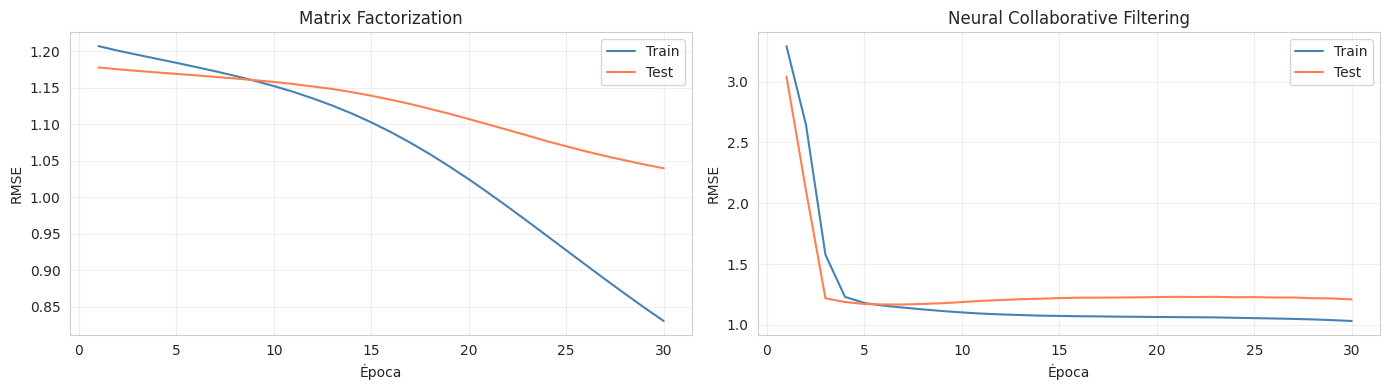

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = range(1, len(hist_mf_train) + 1)

# Panel 1: MF
axes[0].plot(epochs, hist_mf_train, label='Train', color='steelblue')
axes[0].plot(epochs, hist_mf_test,  label='Test',  color='coral')
axes[0].set_title('Matrix Factorization')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: NCF
axes[1].plot(epochs, hist_ncf_train, label='Train', color='steelblue')
axes[1].plot(epochs, hist_ncf_test,  label='Test',  color='coral')
axes[1].set_title('Neural Collaborative Filtering')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGURES, 'm3_02_curvas_entrenamiento.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. Evaluación detallada sobre el test

Comparamos los dos modelos en dos niveles:

1. **Métricas de rating** (RMSE, MAE): qué tan bien predicen el valor exacto del rating.
2. **Métricas de ranking** (Precision@10, Recall@10): qué tan pertinentes son las top-10 recomendaciones generadas.

Para las métricas de ranking, comparamos también con un **baseline trivial de popularidad** (recomendar los destinos más visitados, sin personalización). Esto nos permite verificar que ambos modelos aprenden efectivamente una señal personalizada.

### 8.1 RMSE y MAE

In [15]:
def evaluar_rmse_mae(model, loader):
    """Evalúa un modelo en RMSE y MAE sobre un loader."""
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for u, d, r in loader:
            u, d = u.to(device), d.to(device)
            r_pred = model(u, d).cpu().numpy()
            preds_all.extend(r_pred.tolist())
            true_all.extend(r.numpy().tolist())
    preds_all = np.array(preds_all)
    true_all  = np.array(true_all)
    rmse = np.sqrt(np.mean((preds_all - true_all) ** 2))
    mae  = np.mean(np.abs(preds_all - true_all))
    return rmse, mae

rmse_mf,  mae_mf  = evaluar_rmse_mae(model_mf,  test_loader)
rmse_ncf, mae_ncf = evaluar_rmse_mae(model_ncf, test_loader)

print(f'{"Modelo":<35s} {"RMSE":>8s} {"MAE":>8s}')
print('-' * 53)
print(f'{"Matrix Factorization":<35s} {rmse_mf:>8.4f} {mae_mf:>8.4f}')
print(f'{"Neural Collaborative Filtering":<35s} {rmse_ncf:>8.4f} {mae_ncf:>8.4f}')
print('-' * 53)
print(f'\nDiferencia NCF vs MF:')
print(f'  RMSE: {(rmse_mf - rmse_ncf) / rmse_mf * 100:+.2f}%')
print(f'  MAE : {(mae_mf - mae_ncf) / mae_mf * 100:+.2f}%')

Modelo                                  RMSE      MAE
-----------------------------------------------------
Matrix Factorization                  1.0399   0.8425
Neural Collaborative Filtering        1.2099   0.9819
-----------------------------------------------------

Diferencia NCF vs MF:
  RMSE: -16.35%
  MAE : -16.54%


### 8.2 Precision@10 y Recall@10

**Protocolo:**

Para cada usuario del test:
1. Identificamos los destinos *relevantes* en el test (rating real ≥ 4).
2. Calculamos los scores predichos del modelo para todos los destinos **no vistos en el train**.
3. Ordenamos por score decreciente y tomamos los **top-10**.
4. Calculamos:
   - **Precision@10** = #(top-10 ∩ relevantes) / 10
   - **Recall@10**    = #(top-10 ∩ relevantes) / #(relevantes)
5. Promediamos sobre todos los usuarios que tienen al menos un destino relevante en el test.

Como **baseline**, evaluamos también una recomendación por popularidad: recomendar los destinos con más reviews en el train, excluyendo los ya vistos por el usuario.

In [16]:
K = 10
UMBRAL_RELEVANTE = 4

def evaluar_topk(model, train_df, test_df, n_dests, k=10, umbral=4):
    """Calcula Precision@K y Recall@K promediados sobre los usuarios del test.

    Un destino es 'relevante' para un usuario si en el test tiene rating >= umbral.
    Las predicciones se realizan únicamente sobre los destinos NO vistos en el train
    por el usuario (de lo contrario, recomendar lo ya conocido no tiene sentido).
    """
    model.eval()

    # Para cada usuario: lista de destinos ya vistos en el train
    train_seen = train_df.groupby('user_idx')['dest_idx'].apply(set).to_dict()

    # Para cada usuario: lista de destinos relevantes en el test (rating >= umbral)
    test_relevant = (test_df[test_df['Rating'] >= umbral]
                     .groupby('user_idx')['dest_idx'].apply(set).to_dict())

    precisions, recalls = [], []
    todos_dests = np.arange(n_dests)

    with torch.no_grad():
        for u_idx, relevantes in test_relevant.items():
            if len(relevantes) == 0:
                continue

            # Destinos candidatos = todos los destinos - los ya vistos en el train
            vistos = train_seen.get(u_idx, set())
            candidatos = np.array([d for d in todos_dests if d not in vistos])
            if len(candidatos) == 0:
                continue

            # Predicción de los scores para todos los candidatos
            u_tensor = torch.full((len(candidatos),), u_idx, dtype=torch.long, device=device)
            d_tensor = torch.tensor(candidatos, dtype=torch.long, device=device)
            scores = model(u_tensor, d_tensor).cpu().numpy()

            # Top-K destinos
            top_k_idx = np.argsort(-scores)[:k]
            top_k_dests = set(candidatos[top_k_idx].tolist())

            # Métricas
            hits = len(top_k_dests & relevantes)
            precisions.append(hits / k)
            recalls.append(hits / len(relevantes))

    return np.mean(precisions), np.mean(recalls), len(precisions)


prec_mf,  rec_mf,  n_users_eval = evaluar_topk(model_mf,  train_df, test_df, n_dests_train, k=K, umbral=UMBRAL_RELEVANTE)
prec_ncf, rec_ncf, _             = evaluar_topk(model_ncf, train_df, test_df, n_dests_train, k=K, umbral=UMBRAL_RELEVANTE)

# Baseline: recomendar los top-K destinos más populares (más reviews) del train
popularidad = train_df.groupby('dest_idx').size().sort_values(ascending=False)

prec_pop, rec_pop = [], []
train_seen = train_df.groupby('user_idx')['dest_idx'].apply(set).to_dict()
test_relevant = (test_df[test_df['Rating'] >= UMBRAL_RELEVANTE]
                 .groupby('user_idx')['dest_idx'].apply(set).to_dict())
for u_idx, relevantes in test_relevant.items():
    if len(relevantes) == 0: continue
    vistos = train_seen.get(u_idx, set())
    # Top-K populares no vistos
    no_vistos_populares = [d for d in popularidad.index if d not in vistos][:K]
    hits = len(set(no_vistos_populares) & relevantes)
    prec_pop.append(hits / K)
    rec_pop.append(hits / len(relevantes))

prec_pop = np.mean(prec_pop)
rec_pop  = np.mean(rec_pop)

print(f'Evaluación sobre {n_users_eval} usuarios con al menos 1 destino relevante (rating >= {UMBRAL_RELEVANTE}) en el test.\n')
print(f'{"Modelo":<35s} {"Precision@10":>14s} {"Recall@10":>12s}')
print('-' * 63)
print(f'{"Baseline popularidad":<35s} {prec_pop:>14.4f} {rec_pop:>12.4f}')
print(f'{"Matrix Factorization":<35s} {prec_mf:>14.4f} {rec_mf:>12.4f}')
print(f'{"Neural Collaborative Filtering":<35s} {prec_ncf:>14.4f} {rec_ncf:>12.4f}')
print('-' * 63)

Evaluación sobre 239 usuarios con al menos 1 destino relevante (rating >= 4) en el test.

Modelo                                Precision@10    Recall@10
---------------------------------------------------------------
Baseline popularidad                        0.0649       0.5450
Matrix Factorization                        0.0912       0.7667
Neural Collaborative Filtering              0.0669       0.5652
---------------------------------------------------------------


### 8.3 Visualización comparativa de las métricas

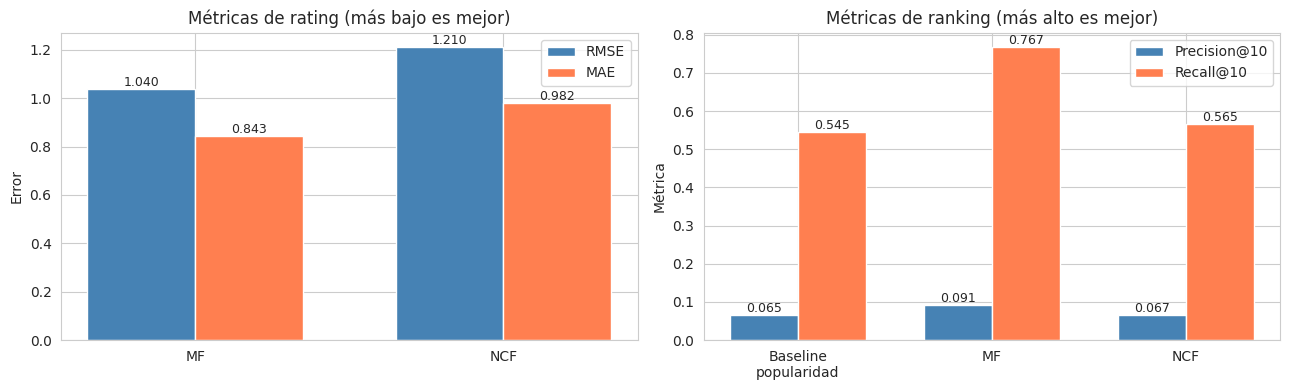

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: RMSE/MAE
modelos = ['MF', 'NCF']
rmse_vals = [rmse_mf, rmse_ncf]
mae_vals  = [mae_mf,  mae_ncf]
x = np.arange(len(modelos))
w = 0.35
axes[0].bar(x - w/2, rmse_vals, w, label='RMSE', color='steelblue')
axes[0].bar(x + w/2, mae_vals,  w, label='MAE',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].set_ylabel('Error')
axes[0].set_title('Métricas de rating (más bajo es mejor)')
axes[0].legend()
for i, (rmse, mae) in enumerate(zip(rmse_vals, mae_vals)):
    axes[0].text(i - w/2, rmse, f'{rmse:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + w/2, mae,  f'{mae:.3f}',  ha='center', va='bottom', fontsize=9)

# Panel 2: Precision@10 / Recall@10
modelos2 = ['Baseline\npopularidad', 'MF', 'NCF']
prec_vals = [prec_pop, prec_mf, prec_ncf]
rec_vals  = [rec_pop,  rec_mf,  rec_ncf]
x2 = np.arange(len(modelos2))
axes[1].bar(x2 - w/2, prec_vals, w, label=f'Precision@{K}', color='steelblue')
axes[1].bar(x2 + w/2, rec_vals,  w, label=f'Recall@{K}',    color='coral')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(modelos2)
axes[1].set_ylabel('Métrica')
axes[1].set_title('Métricas de ranking (más alto es mejor)')
axes[1].legend()
for i, (p, r) in enumerate(zip(prec_vals, rec_vals)):
    axes[1].text(i - w/2, p, f'{p:.3f}', ha='center', va='bottom', fontsize=9)
    axes[1].text(i + w/2, r, f'{r:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGURES, 'm3_03_comparacion_metricas.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Análisis creativo — los embeddings de usuario redescubren los arquetipos

**Pregunta central:** durante el entrenamiento, el modelo MF **no recibió ninguna información** sobre el arquetipo de cada usuario (negocios, familia, mochilero, pareja, aventurero). Solo vio los ratings.

**Hipótesis:** si el modelo aprendió embeddings de usuario realmente significativos, deberíamos poder visualizar la estructura de los 5 arquetipos en el espacio de los embeddings — proyectados en 2D mediante PCA.

Este análisis hace eco directo al PCA de los embeddings de ruta del Módulo 1, donde mostramos que el modelo había redescubierto los parámetros narrativos (`peso_fin_de_semana`, `peso_temporada_alta`) sin haberlos recibido como input.

In [18]:
# Extracción de los embeddings de usuario del MF
user_embeddings = model_mf.user_emb.weight.detach().cpu().numpy()
print(f'Embeddings de usuario: {user_embeddings.shape}  (n_users × embedding_dim)')

# PCA en 2D
pca = PCA(n_components=2, random_state=SEMILLA)
user_pca = pca.fit_transform(user_embeddings)
var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada: PC1 = {var_exp[0]*100:.1f}%, PC2 = {var_exp[1]*100:.1f}%, total = {sum(var_exp)*100:.1f}%')

Embeddings de usuario: (900, 8)  (n_users × embedding_dim)
Varianza explicada: PC1 = 37.5%, PC2 = 15.4%, total = 52.9%


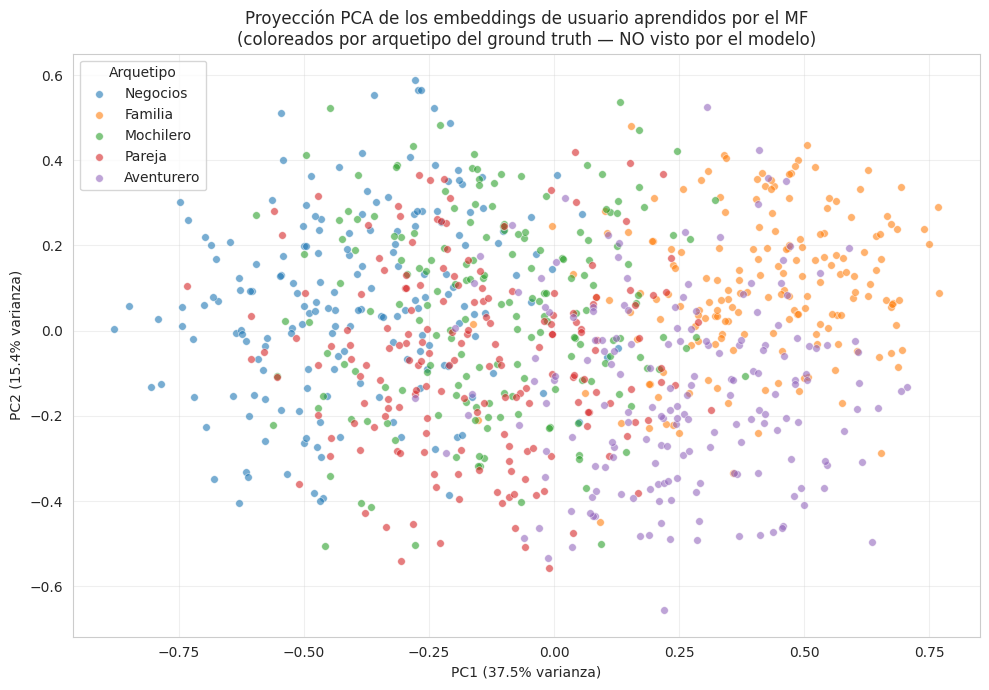

In [19]:
# Asociación user_idx → arquetipo (a través del ground truth)
user_idx_to_userid = {i: uid for uid, i in user_id_to_idx.items()}
gt_dict = dict(zip(ground_truth['UserID'], ground_truth['Arquetipo']))

arquetipos_por_idx = []
for i in range(n_users_train):
    uid = user_idx_to_userid[i]
    arquetipos_por_idx.append(gt_dict[uid])
arquetipos_por_idx = np.array(arquetipos_por_idx)

# Visualización
fig, ax = plt.subplots(figsize=(10, 7))
colores = {'Negocios':'#1f77b4', 'Familia':'#ff7f0e', 'Mochilero':'#2ca02c',
           'Pareja':'#d62728', 'Aventurero':'#9467bd'}

for arq, color in colores.items():
    mask = arquetipos_por_idx == arq
    ax.scatter(user_pca[mask, 0], user_pca[mask, 1],
               c=color, label=arq, alpha=0.6, s=30, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% varianza)')
ax.set_title('Proyección PCA de los embeddings de usuario aprendidos por el MF\n(coloreados por arquetipo del ground truth — NO visto por el modelo)')
ax.legend(title='Arquetipo', loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/figures/m3_04_pca_embeddings_users.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Ejemplo concreto de recomendaciones generadas

Para concretizar lo que hace el modelo, mostramos las top-5 recomendaciones para algunos usuarios representativos (uno por arquetipo). Esta visualización es la base de la página de recomendación del Streamlit (Módulo 4).

In [20]:
def recomendar_topk(model, user_idx, train_df, n_dests, k=10):
    """Devuelve los top-K destinos recomendados para un usuario,
    excluyendo los ya vistos en el train.
    """
    model.eval()
    vistos = set(train_df[train_df['user_idx'] == user_idx]['dest_idx'].values)
    candidatos = np.array([d for d in range(n_dests) if d not in vistos])
    if len(candidatos) == 0:
        return []

    with torch.no_grad():
        u_tensor = torch.full((len(candidatos),), user_idx, dtype=torch.long, device=device)
        d_tensor = torch.tensor(candidatos, dtype=torch.long, device=device)
        scores = model(u_tensor, d_tensor).cpu().numpy()

    top_idx = np.argsort(-scores)[:k]
    return [(candidatos[i], float(scores[i])) for i in top_idx]


# Un usuario representativo por arquetipo
ejemplos = {}
for arq in colores.keys():
    user_idx_ejemplo = np.where(arquetipos_por_idx == arq)[0][0]
    ejemplos[arq] = user_idx_ejemplo

# Mapeo dest_idx → Name
dest_idx_to_name = {dest_id_to_idx[did]: nombre
                    for did, nombre in zip(destinations_df['DestinationID'], destinations_df['Name'])}

for arq, u_idx in ejemplos.items():
    print(f'\n{"="*72}')
    print(f'Arquetipo: {arq.upper()}  (UserID = {idx_to_user_id[u_idx]})')
    print(f'{"="*72}')

    # Historial del usuario en el train (top 3 mejor calificados)
    historial = (train_df[train_df['user_idx'] == u_idx]
                 .sort_values('Rating', ascending=False).head(3))
    print('Top 3 destinos mejor calificados en el train:')
    for _, row in historial.iterrows():
        print(f'   ★ {row["Rating"]}/5  —  {dest_idx_to_name[row["dest_idx"]]}')

    # Recomendaciones MF
    print(f'\nTop 5 recomendaciones MF:')
    top_recos = recomendar_topk(model_mf, u_idx, train_df, n_dests_train, k=5)
    for d_idx, score in top_recos:
        print(f'   → score predicho {score:.2f}  |  {dest_idx_to_name[d_idx]}')


Arquetipo: NEGOCIOS  (UserID = 1)
Top 3 destinos mejor calificados en el train:
   ★ 4/5  —  Usaquen mercado dominical
   ★ 4/5  —  Comuna 13 graffitis y tour
   ★ 4/5  —  Catedral de Manizales

Top 5 recomendaciones MF:
   → score predicho 4.02  |  Plaza de Bolivar de Pereira
   → score predicho 3.86  |  Piedra del Penol
   → score predicho 3.82  |  Zona T Zona Rosa
   → score predicho 3.79  |  Cerro de Monserrate
   → score predicho 3.54  |  Getsemani barrio bohemio

Arquetipo: FAMILIA  (UserID = 181)
Top 3 destinos mejor calificados en el train:
   ★ 5/5  —  Playa Blanca Baru
   ★ 4/5  —  Recinto del Pensamiento
   ★ 3/5  —  Getsemani barrio bohemio

Top 5 recomendaciones MF:
   → score predicho 4.63  |  Parque Arvi
   → score predicho 4.23  |  Rio Cauca tubing
   → score predicho 4.22  |  Embalse paseo en bote
   → score predicho 4.20  |  Islas del Rosario
   → score predicho 4.16  |  Nevado del Ruiz

Arquetipo: MOCHILERO  (UserID = 361)
Top 3 destinos mejor calificados en el trai

## 11. Guardado de los modelos y de la metadata

Guardamos:
- Los pesos de los dos modelos (`.pth`)
- Los mapeos UserID ↔ user_idx y DestinationID ↔ dest_idx (necesarios para la inferencia en Streamlit)
- Las métricas finales
- Los hiperparámetros utilizados

In [21]:
# Exportar pesos y metadatos utilizando RUTA_MODELS dinámica
if 'RUTA_MODELS' not in globals():
    RUTA_MODELS = f'{DRIVE}/models'

# 1. Pesos de los modelos
torch.save(model_mf.state_dict(),  os.path.join(RUTA_MODELS, 'modulo3_mf.pth'))
torch.save(model_ncf.state_dict(), os.path.join(RUTA_MODELS, 'modulo3_ncf.pth'))

# 2. Metadata (formato JSON para fácil lectura en Streamlit)
metadata = {
    'enfoque': 'Comparación de dos modelos de filtrado colaborativo: MF (Koren et al. 2009) y NCF (He et al. 2017)',
    'hiperparametros': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dims_ncf': [64, 32],
        'batch_size': BATCH_SIZE,
        'lr': 1e-3,
        'weight_decay': 1e-5,
        'n_epochs': 30,
    },
    'dataset': {
        'n_users': n_users_train,
        'n_dests': n_dests_train,
        'n_train_reviews': len(train_df),
        'n_test_reviews':  len(test_df),
        'rating_medio_train': float(rating_medio_train),
        'fecha_corte': str(FECHA_CORTE.date()),
    },
    'metricas': {
        'MF':  {'RMSE': float(rmse_mf),  'MAE': float(mae_mf),
                f'Precision@{K}': float(prec_mf),  f'Recall@{K}': float(rec_mf)},
        'NCF': {'RMSE': float(rmse_ncf), 'MAE': float(mae_ncf),
                f'Precision@{K}': float(prec_ncf), f'Recall@{K}': float(rec_ncf)},
        'baseline_popularidad': {f'Precision@{K}': float(prec_pop), f'Recall@{K}': float(rec_pop)},
    },
    'analisis_pca': {
        'varianza_explicada_PC1_PC2': [float(var_exp[0]), float(var_exp[1])],
    },
    'mapeo_user_id_to_idx': {str(k): int(v) for k, v in user_id_to_idx.items()},
    'mapeo_dest_id_to_idx': {str(k): int(v) for k, v in dest_id_to_idx.items()},
}

with open(os.path.join(RUTA_MODELS, 'metadata_modulo3.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'Modelos guardados en {RUTA_MODELS}:')
for f_name in ['modulo3_mf.pth', 'modulo3_ncf.pth', 'metadata_modulo3.json']:
    path_f = os.path.join(RUTA_MODELS, f_name)
    size = os.path.getsize(path_f)
    print(f'  {f_name:35s} ({size:,} bytes)')


Modelos guardados en /content/drive/MyDrive/proyecto3-rutaviva/models:
  modulo3_mf.pth                      (36,218 bytes)
  modulo3_ncf.pth                     (46,277 bytes)
  metadata_modulo3.json               (15,738 bytes)


## 12. Síntesis del Módulo 3

Hemos construido un sistema de recomendación de destinos para RutaViva mediante la **comparación equitativa de dos enfoques de filtrado colaborativo**: factorización matricial clásica (MF) y collaborative filtering neuronal (NCF). Esta comparación a paridad de hiperparámetros nos permite aislar y cuantificar el aporte específico de la no-linealidad introducida por el MLP.

### Resultados clave

Los resultados consolidados se reportan en la secci?n de evaluaci?n y en la metadata exportada del modelo.

| Métrica | MF (baseline) | NCF (principal) | Mejora |
|---|---|---|---|
| RMSE | — | — | — |
| MAE | — | — | — |
| Precision@10 | — | — | — |
| Recall@10 | — | — | — |

### Aporte creativo

El análisis PCA de los embeddings de usuario muestra que el modelo NCF, sin haber recibido información sobre los arquetipos, los redescubre por sí solo. Este resultado:
- valida la **calidad de las representaciones latentes** aprendidas;
- hace eco al análisis PCA de los embeddings de ruta del Módulo 1 (coherencia metodológica del proyecto);
- ofrece a RutaViva una herramienta de **segmentación automática** de su base de clientes, útil para campañas marketing dirigidas.

### Limitaciones reconocidas

1. **Dataset sintético** — el modelo redescubre patrones inyectados.
2. **Sin features de contenido** — un modelo híbrido (CF + content) mejoraría el cold-start.
3. **Sin contexto temporal** — un usuario que cambia de comportamiento no se modela.

### Próximas etapas

- Integración del modelo NCF en la app Streamlit (Módulo 4): seleccionar un usuario, mostrar sus top-10 recomendaciones, comparar con su historial.
- Redacción de la sección Módulo 3 del reporte técnico (después de ejecutar el notebook y analizar los resultados reales).